# KDHS 2022 — Contraceptive Use Prediction
## Data Cleaning, EDA, Modelling & Deployment
### The Insight Architects Group

---

**Dataset:** Kenya Demographic and Health Survey (KDHS) 2022 — Women's Questionnaire  
**Respondents:** 32,156 women aged 15–49 across all 47 counties  
**Target Variable:** `contraceptive_use` — Type of contraceptive method currently used  
**Methodology:** CRISP-DM  
**Tools:** Python · scikit-learn · LightGBM · SHAP · Flask

---

## 1. Business Understanding

### 1.1 Business Overview

Kenya has made significant progress in family planning over the past three decades, yet contraceptive uptake remains deeply unequal across the country's 47 counties. The 2022 Kenya Demographic and Health Survey (KDHS), a nationally representative dataset of 32,156 women aged 15–49, captures this inequality in unprecedented detail — recording sociodemographic variables such as education, wealth, residence, marital status, and county of residence alongside contraceptive use patterns. Since manual analysis of such a large, multi-variable dataset is impractical for health planners, machine learning can be used to automatically identify the sociodemographic profiles of women most at risk of contraceptive non-use.

This project develops a contraceptive use prediction model using the 2022 KDHS dataset to help the Ministry of Health and family planning partners identify underserved population segments and deploy targeted interventions efficiently and at scale.

### 1.2 Problem Statement

Kenya's modern contraceptive prevalence rate among married women is approximately 60% nationally, but this average conceals major geographic and socioeconomic inequalities. In arid and semi-arid counties such as Turkana, West Pokot, and Mandera, contraceptive uptake falls 20–30 percentage points below the national average, while more urbanised counties like Nairobi and Kiambu report markedly higher rates. Without a data-driven segmentation of at-risk populations, health interventions are distributed uniformly rather than targeted where they are needed most.

**Key challenges include:**

- **Class imbalance** — modern method users (38%) significantly outnumber folkloric and traditional method users (4% combined)
- **High dimensionality** — 5,925 variables in the raw survey requiring careful feature selection down to the most relevant predictors
- **Multicollinearity** — closely related variables such as age, children ever born, and marital status overlap in predictive power
- **Categorical encoding** — ordinal variables like wealth index and education level require careful treatment to preserve their natural ordering

**Objective:** Our objective is to build a model that accurately predicts contraceptive use among Kenyan women aged 15–49 using sociodemographic features, and to identify which factors most strongly drive or prevent modern contraceptive uptake.

### 1.3 Stakeholders

| Stakeholder | How They Use This Model |
|---|---|
| Kenya Ministry of Health — Division of Reproductive Health | Identify counties and demographic groups with highest predicted non-use; allocate field officers and resources accordingly |
| County Health Management Teams (all 47 counties) | Generate county-specific risk profiles to guide local family planning outreach programmes |
| UNFPA Kenya Country Office | Target funding and technical assistance toward highest-risk population segments |
| USAID Kenya | Use model outputs to evaluate programme effectiveness and redirect investments to underserved regions |
| FP2030 Programme | Monitor progress toward family planning targets by tracking predicted non-use rates over time |
| Community Health Promoters (CHPs) | Use county-level risk scores to prioritise household visits in high-risk clusters |

### 1.4 Success Metrics

The model will be considered successful if:

- **Accuracy ≥ 78%** on the held-out test set
- **ROC-AUC ≥ 0.82**, measuring the model's ability to distinguish users from non-users
- **Macro F1-Score ≥ 0.75**, ensuring minority classes are not neglected
- **Balanced Precision and Recall**, especially for non-use prediction — failing to identify at-risk women has real public health consequences
- **SHAP explanations identify at least 5 key features** that policymakers can directly act on
- The model generalises to unseen data via stratified 5-fold cross-validation
- The model improves over a simple logistic regression baseline

### 1.5 Key Business Questions

1. What is the overall distribution of contraceptive use types (modern, traditional, folkloric, none) among Kenyan women aged 15–49?
2. Which counties have the highest predicted rates of contraceptive non-use, and what sociodemographic profiles characterise these women?
3. How do education level and wealth index jointly influence the likelihood of modern contraceptive use?
4. Does urban or rural residence remain a significant predictor of contraceptive use when controlling for wealth and education?
5. Which machine learning model best predicts contraceptive use, and which sociodemographic features are the strongest predictors according to SHAP analysis?

---

## Notebook Structure

| # | Section | CRISP-DM Phase |
|---|---|---|
| 1 | Setup & Imports | — |
| 2 | Data Loading & Initial Inspection | Data Understanding |
| 3 | Pre-Cleaning Audit | Data Understanding |
| 4 | Data Cleaning Pipeline | Data Preparation |
| 5 | Post-Cleaning Validation | Data Preparation |
| 6 | Before vs. After Comparison | Data Preparation |
| 7 | EDA — Univariate | Data Understanding |
| 8 | EDA — Bivariate | Data Understanding |
| 9 | EDA — Multivariate | Data Understanding |
| 10 | Key EDA Findings & Modelling Implications | Data Understanding |
| 11 | Feature Engineering | Data Preparation |
| 12 | Train / Test Split & Class Imbalance Handling | Data Preparation |
| 13 | Baseline Model — Logistic Regression | Modelling |
| 14 | Model 2 — Random Forest | Modelling |
| 15 | Model 3 — LightGBM (Tuned) | Modelling |
| 16 | Model Comparison & Selection | Evaluation |
| 17 | SHAP Explainability | Evaluation |
| 18 | Business Recommendations | Evaluation |
| 19 | Deployment — Flask API | Deployment |

## 2. Setup & Imports

In [44]:
! pip install shap

In [45]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings, joblib

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (9, 5)
os.makedirs('images', exist_ok=True)

# Modelling
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve)
import shap

print('Libraries imported successfully')

Libraries imported successfully


## 3. Data Understanding

The raw file has 5,925 columns. We have loaded only the 17 theory-driven predictors plus the target and the unique respondent id `caseid`. Variable codes were verified against the **DHS-7 Standard Recode Manual**.

#### Data Loading

In [46]:
# Selected DHS variables (verified against the DHS-7 Recode Manual)
cols_needed = ['caseid','v012','v013','v024','v025','v106','v190','v501','v502',
               'v201','v218','v228','v714','v136','v130','v151',
               'v701','v212','v302a','v313']

df = pd.read_csv('KDHS_2022_women.csv', usecols=cols_needed, low_memory=False)

df.rename(columns={
    'v012':'age', 'v013':'age_group', 'v024':'county', 'v025':'residence_type',
    'v106':'education_level', 'v190':'wealth_index', 'v501':'marital_status',
    'v502':'union_status', 'v201':'children_ever_born', 'v218':'living_children',
    'v228':'pregnancy_loss', 'v714':'currently_working', 'v136':'household_size',
    'v130':'religion', 'v151':'household_head_sex', 'v701':'partner_education',
    'v212':'age_first_birth', 'v302a':'ever_used_contraceptive', 'v313':'contraceptive_use'
}, inplace=True)

print('Shape:', df.shape)
df.head()

Shape: (32156, 20)


,caseid,age,age_group,county,residence_type,education_level,religion,household_size,household_head_sex,wealth_index,children_ever_born,age_first_birth,living_children,pregnancy_loss,ever_used_contraceptive,contraceptive_use,marital_status,union_status,partner_education,currently_working
0,1 4 2,34,4,1,1,0,7,6,1,4,4,21.0,4,0,0,0,1,1,0.0,0
1,1 7 2,38,5,1,1,2,1,3,1,5,1,22.0,1,1,2,3,1,1,3.0,0
2,1 10 1,33,4,1,1,1,1,2,2,5,1,21.0,1,0,2,3,4,2,NaN,1
3,1 13 2,39,5,1,1,2,1,8,1,5,5,19.0,5,0,2,3,1,1,1.0,1
4,1 20 2,30,4,1,1,1,96,4,1,4,2,20.0,2,0,0,0,2,1,1.0,1


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32156 entries, 0 to 32155
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   caseid                   32156 non-null  object 
 1   age                      32156 non-null  int64  
 2   age_group                32156 non-null  int64  
 3   county                   32156 non-null  int64  
 4   residence_type           32156 non-null  int64  
 5   education_level          32156 non-null  int64  
 6   religion                 32156 non-null  int64  
 7   household_size           32156 non-null  int64  
 8   household_head_sex       32156 non-null  int64  
 9   wealth_index             32156 non-null  int64  
 10  children_ever_born       32156 non-null  int64  
 11  age_first_birth          23343 non-null  float64
 12  living_children          32156 non-null  int64  
 13  pregnancy_loss           32156 non-null  int64  
 14  ever_used_contraceptiv

#### A quick numeric summary

We take a look at the numeric columns to see their ranges before we clean anything. Some of these are still in code form at this point (for example education and wealth are stored as numbers), so this is mainly to check the ranges and spot anything unusual

In [48]:
print("Rows and columns:", df.shape)
df.describe().T

Rows and columns: (32156, 20)


,count,mean,std,min,25%,50%,75%,max
age,32156.0,29.142617,9.546172,15.0,21.0,28.0,36.0,49.0
age_group,32156.0,3.439327,1.895748,1.0,2.0,3.0,5.0,7.0
county,32156.0,24.814716,13.788612,1.0,13.0,26.0,37.0,47.0
residence_type,32156.0,1.614815,0.486647,1.0,1.0,2.0,2.0,2.0
education_level,32156.0,1.545963,0.888795,0.0,1.0,2.0,2.0,3.0
religion,32156.0,5.366401,14.473739,1.0,2.0,2.0,4.0,96.0
household_size,32156.0,5.424555,2.645393,1.0,4.0,5.0,7.0,24.0
household_head_sex,32156.0,1.383692,0.486292,1.0,1.0,1.0,2.0,2.0
wealth_index,32156.0,2.967160,1.416338,1.0,2.0,3.0,4.0,5.0
children_ever_born,32156.0,2.406425,2.364101,0.0,0.0,2.0,4.0,15.0


#### Data preview

In [49]:
# 4.1 Missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0])

Missing values per column:
age_first_birth       8813
partner_education    14039
dtype: int64


In [50]:
# 4.2 Target distribution (raw codes: 0 None, 1 Folkloric, 2 Traditional, 3 Modern)
target_labels = {0:'No method', 1:'Folkloric', 2:'Traditional', 3:'Modern'}
print('Target (contraceptive_use) distribution:')
print(df['contraceptive_use'].map(target_labels).value_counts())
print()
print((df['contraceptive_use'].map(target_labels).value_counts(normalize=True)*100).round(1))

Target (contraceptive_use) distribution:
No method      18694
Modern         12195
Traditional     1214
Folkloric         53
Name: contraceptive_use, dtype: int64

No method      58.1
Modern         37.9
Traditional     3.8
Folkloric       0.2
Name: contraceptive_use, dtype: float64


In [51]:
# 4.3 Are the 274 "duplicates" real duplicates, or just women with similar profiles?

# pandas flags 274 rows that repeat an earlier row (this is what .duplicated() counts):
print('Rows pandas would call duplicates:', df.drop(columns='caseid').duplicated().sum())

# Now marking all rows involved in a look-alike (both the original AND its copy):
look_alike = df.drop(columns='caseid').duplicated(keep=False)
print('Total rows that have a look-alike:', look_alike.sum())

# If these were real duplicates, the IDs would repeat.
# Checking how many DIFFERENT women (unique caseids) these rows actually are:
print('Number of different women among them:', df.loc[look_alike, 'caseid'].nunique())

Rows pandas would call duplicates: 274
Total rows that have a look-alike: 532
Number of different women among them: 532


**Finding: there are no real duplicates.**

pandas flags 274 rows as "duplicates," and in total 532 rows share a look-alike profile. But when we check their IDs, all 532 belong to **different women** (532 unique `caseid`s). They simply share the same age, county, education, and so on.

It is like two students who are both "16, from Nairobi, in Form 3" , they look the same on paper, but they are still two different people with two different admission numbers (`caseid`).

So we have not dropped these rows. Deleting them would throw away real survey responses. No rows are removed.

## 4. Data Cleaning  

For our cleaning we made three deliberate, well-reasoned decisions:
1. **Decoding** the numeric DHS codes into readable labels.
2. **Treating the structural missing data correctly** — the missing values are "not applicable", not gaps.
3. **Keeping the apparent duplicates** (justified above).

#### 4.1 Decoding categorical codes
Codes for the standard variables were confirmed in the DHS-7 manual. `county` and `religion` use Kenya's country-specific codes (constitutional county order 1=Mombasa … 47=Nairobi).

In [52]:
label_maps = {
    'residence_type':     {1:'Urban', 2:'Rural'},
    'education_level':    {0:'No education', 1:'Primary', 2:'Secondary', 3:'Higher'},
    'wealth_index':       {1:'Poorest', 2:'Poorer', 3:'Middle', 4:'Richer', 5:'Richest'},
    'household_head_sex': {1:'Male', 2:'Female'},
    'currently_working':  {0:'No', 1:'Yes'},
    'pregnancy_loss':     {0:'No', 1:'Yes'},
    'marital_status':     {0:'Never married', 1:'Married', 2:'Living together',
                           3:'Widowed', 4:'Divorced', 5:'Separated'},
    'union_status':       {0:'Never in union', 1:'Currently in union', 2:'Formerly in union'},
    'age_group':          {1:'15-19',2:'20-24',3:'25-29',4:'30-34',5:'35-39',6:'40-44',7:'45-49'},
    'contraceptive_use':  {0:'No method', 1:'Folkloric', 2:'Traditional', 3:'Modern'},
    'religion':           {1:'Roman Catholic', 2:'Protestant/Other Christian',
                           3:'Evangelical/Born Again', 4:'African Instituted Church',
                           5:'Orthodox', 7:'Muslim', 8:'Hindu', 9:'Traditionalist',
                           10:'No religion', 96:'Other'},
}
county_map = {1:'Mombasa',2:'Kwale',3:'Kilifi',4:'Tana River',5:'Lamu',6:'Taita Taveta',
 7:'Garissa',8:'Wajir',9:'Mandera',10:'Marsabit',11:'Isiolo',12:'Meru',13:'Tharaka-Nithi',
 14:'Embu',15:'Kitui',16:'Machakos',17:'Makueni',18:'Nyandarua',19:'Nyeri',20:'Kirinyaga',
 21:"Murang'a",22:'Kiambu',23:'Turkana',24:'West Pokot',25:'Samburu',26:'Trans Nzoia',
 27:'Uasin Gishu',28:'Elgeyo Marakwet',29:'Nandi',30:'Baringo',31:'Laikipia',32:'Nakuru',
 33:'Narok',34:'Kajiado',35:'Kericho',36:'Bomet',37:'Kakamega',38:'Vihiga',39:'Bungoma',
 40:'Busia',41:'Siaya',42:'Kisumu',43:'Homa Bay',44:'Migori',45:'Kisii',46:'Nyamira',47:'Nairobi'}

for col, m in label_maps.items():
    df[col] = df[col].map(m)
df['county'] = df['county'].map(county_map)

# Ever-used (V302A): behavioural pattern variable, decoded for EDA only.
df['ever_used_contraceptive'] = df['ever_used_contraceptive'].map(
    {0:'Never used', 1:'Used previously', 2:'Currently using'})

print('Decoded. Example rows:')
df[['county','education_level','wealth_index','marital_status','contraceptive_use']].head()

Decoded. Example rows:


,county,education_level,wealth_index,marital_status,contraceptive_use
0,Mombasa,No education,Richer,Married,No method
1,Mombasa,Secondary,Richest,Married,Modern
2,Mombasa,Primary,Richest,Divorced,Modern
3,Mombasa,Secondary,Richest,Married,Modern
4,Mombasa,Primary,Richer,Living together,No method


#### 4.2 Checking for Missing Values

Two columns have missing values — but the gaps are **not mistakes** in the data. They are simply cases where the question **did not apply** to that woman. So instead of deleting rows or guessing values, we have handled each one in a way that makes sense.

**`age_first_birth` — 8,813 missing.** This is the age a woman was when she had her first child. Every single missing value belongs to a woman who has **never had a child** — so of course she has no "age at first birth." It is blank for a real reason, not by error.
What we did: we created a new yes/no column `has_given_birth` to record whether she has ever given birth, then filled the blank with `0` to mean "not applicable." (Filling it with an average age instead would pretend these women had given birth, which is wrong.)

**`partner_education` — 14,039 missing.** This is the education level of a woman's partner. Most of these blanks (13,844) are women who have **no current partner** — so there is no partner's education to record. Only about 195 are truly missing.
What we did: instead of guessing, we added a clear new category called **"No partner"** so the information is honest and complete.

After this step, the dataset has **zero** missing values.

In [53]:
# --- age_first_birth ---
# Confirming that every missing value is a woman with no children.
missing_afb = df['age_first_birth'].isna()
print('age_first_birth missing:', missing_afb.sum(),
      '| of those with 0 children:', (df.loc[missing_afb, 'children_ever_born'] == 0).sum())

# Making a yes/no column for "has she ever given birth?", then fill the blank with 0 = "not applicable".
df['has_given_birth'] = df['age_first_birth'].notna().astype(int)
df['age_first_birth'] = df['age_first_birth'].fillna(0)

# --- partner_education ---
# Turning the codes into labels, and fill the blanks with a clear "No partner" category.
df['partner_education'] = df['partner_education'].map(
    {0: 'No education', 1: 'Primary', 2: 'Secondary', 3: 'Higher'}).fillna('No partner')

# Checking: there should now be no missing values left anywhere.
print('Remaining missing values in full frame:', int(df.isnull().sum().sum()))

age_first_birth missing: 8813 | of those with 0 children: 8813
Remaining missing values in full frame: 0


#### 4.3 Keeping all rows (no de-duplication) 

In [54]:
print('Rows retained (no rows dropped):', df.shape[0])

Rows retained (no rows dropped): 32156


#### 4.4 Post-Cleaning Validation

In [55]:
assert df.isnull().sum().sum() == 0, 'There are still missing values!'
assert df.shape[0] == 32156, 'Row count changed unexpectedly!'
print('Validation passed.')
print('Final shape:', df.shape)
print('\nDtypes:\n', df.dtypes)

Validation passed.
Final shape: (32156, 21)

Dtypes:
 caseid                      object
age                          int64
age_group                   object
county                      object
residence_type              object
education_level             object
religion                    object
household_size               int64
household_head_sex          object
wealth_index                object
children_ever_born           int64
age_first_birth            float64
living_children              int64
pregnancy_loss              object
ever_used_contraceptive     object
contraceptive_use           object
marital_status              object
union_status                object
partner_education           object
currently_working           object
has_given_birth              int32
dtype: object


#### 4.5. Before cleaning and after cleaning  Comparison

In [56]:
summary = pd.DataFrame({
    'Stage': ['Raw', 'Cleaned'],
    'Rows': [32156, df.shape[0]],
    'Columns': [20, df.shape[1]],
    'Missing values': [8813+14039, int(df.isnull().sum().sum())],
})
summary

,Stage,Rows,Columns,Missing values
0,Raw,32156,20,22852
1,Cleaned,32156,21,0


## 5. Exploratory Data Analysis

Before we build any models, we spend some time getting to know the cleaned dataset. In this section we look at how the different variables are spread out, what patterns show up, and how they relate to contraceptive use among women in Kenya.
What we find here helps us decide which features to use and how to approach the modelling in the next sections.

#### Univariate Analysis


5.1 Distribution of contaceptive use(Target Variable) 

Business Question 1:What is the overall distribution of contraceptive use types (modern, traditional, folkloric, none) among Kenyan women aged 15–49?


We start by looking at how contraceptive use is spread across the four types. This matters because it tells us whether we have a class imbalance problem, where some types have far more women than others, which is something we will need to deal with before modelling.

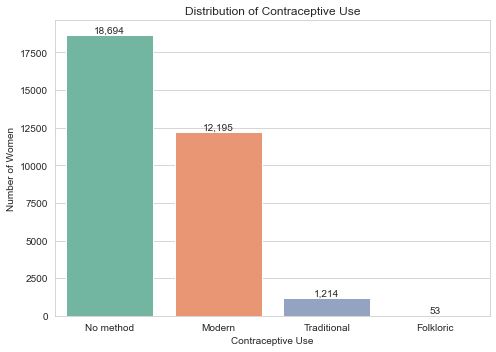

Percentage of each type:
No method      58.1
Modern         37.9
Traditional     3.8
Folkloric       0.2
Name: contraceptive_use, dtype: float64


In [57]:
# --------------------------------------
# Distribution of Target Variable
# --------------------------------------

plt.figure(figsize=(7,5))

# ordering the bars from the most common type to the least common
order = df['contraceptive_use'].value_counts().index

ax = sns.countplot(
    x='contraceptive_use',
    data=df,
    order=order
)

# adding the count on top of each bar so the numbers are easy to read
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title("Distribution of Contraceptive Use")
plt.xlabel("Contraceptive Use")
plt.ylabel("Number of Women")
plt.tight_layout()
plt.show()

# looking at the same breakdown as percentages
print("Percentage of each type:")
print((df['contraceptive_use'].value_counts(normalize=True) * 100).round(1))

##### Insight
Most women fall into just two groups, "No method" (18,694) and "Modern" (12,195), while "Traditional" (1,214) and especially "Folkloric" (53) are very small. This is a clear class imbalance. 


#### 5.2 Age Distribution

Age is one of the strongest  features linked to contraceptive use, so we look at how old the women in the sample are.

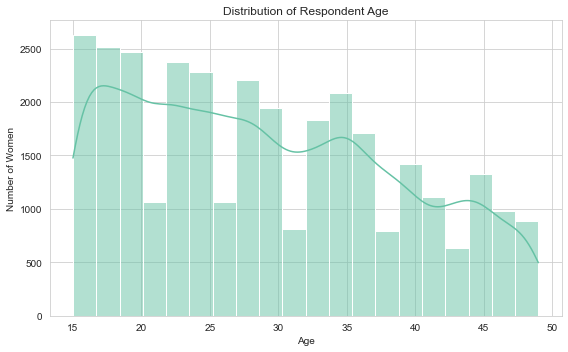

Average age: 29.1 | Median age: 28


In [58]:
# --------------------------------------
# Age Distribution
# --------------------------------------

plt.figure(figsize=(8,5))

# plotting the ages with a smooth line on top to show the shape
sns.histplot(df['age'], bins=20, kde=True)

plt.title("Distribution of Respondent Age")
plt.xlabel("Age")
plt.ylabel("Number of Women")
plt.tight_layout()
plt.savefig('images/age_distribution.png', dpi=120)
plt.show()

print("Average age:", round(df['age'].mean(), 1), "| Median age:", int(df['age'].median()))

##### Insight
Most of the women are in their twenties (average age about 29, median 28), and the numbers thin out towards 49. That fits the survey, since it only covers women of reproductive age (15 to 49). Because use of contraception changes a lot with age, age should be a useful predictor later.

#### 5.3 Education Level

Here we see how far the women in the sample went in school.

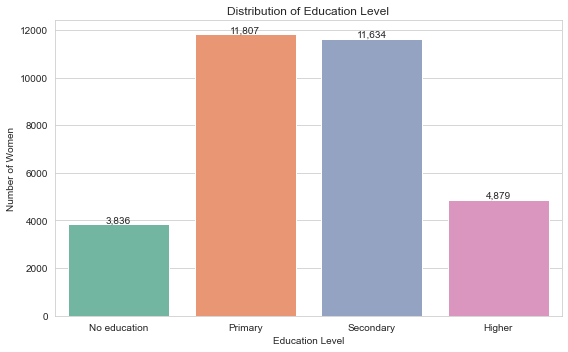

Primary         36.7
Secondary       36.2
Higher          15.2
No education    11.9
Name: education_level, dtype: float64


In [59]:
# --------------------------------------
# Education Level
# --------------------------------------

edu_order = ['No education', 'Primary', 'Secondary', 'Higher']

plt.figure(figsize=(8,5))
ax = sns.countplot(data=df, x='education_level', order=edu_order)

# writing the count on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title("Distribution of Education Level")
plt.xlabel("Education Level")
plt.ylabel("Number of Women")
plt.tight_layout()
plt.savefig('images/education_distribution.png', dpi=120)
plt.show()

print((df['education_level'].value_counts(normalize=True) * 100).round(1))

##### Insight
Primary and secondary are the most common levels (about 37% each), higher education is about 15%, and roughly 12% of the women have no education at all.Since education influences health awareness and access to reproductive health information, this variable is expected to play an important role in predicting contraceptive use. These findings suggest that education should be retained as an important predictor during model development.

#### 5.4 Wealth Index

The wealth index groups households from poorest to richest. We check that every group is well represented.

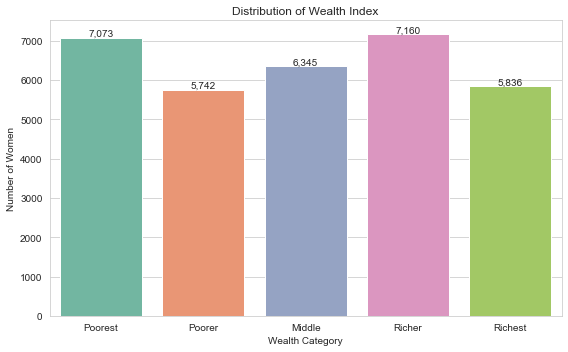

Richer     22.3
Poorest    22.0
Middle     19.7
Richest    18.1
Poorer     17.9
Name: wealth_index, dtype: float64


In [60]:
# --------------------------------------
# Wealth Index
# --------------------------------------

wealth_order = ['Poorest', 'Poorer', 'Middle', 'Richer', 'Richest']

plt.figure(figsize=(8,5))
ax = sns.countplot(data=df, x='wealth_index', order=wealth_order)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title("Distribution of Wealth Index")
plt.xlabel("Wealth Category")
plt.ylabel("Number of Women")
plt.tight_layout()
plt.savefig('images/wealth_distribution.png', dpi=120)
plt.show()

print((df['wealth_index'].value_counts(normalize=True) * 100).round(1))

##### Insight
The five wealth groups are fairly evenly represented (each is roughly 18 to 22% of the sample), so we have enough women in every economic group to compare them fairly. The wealth index may therefore have a significant relationship with contraceptive uptake and is an important feature for predictive modelling. The balanced representation across wealth categories reduces the likelihood of biased model predictions

#### 5.5 Residence Type

We also check how many women live in urban versus rural areas.

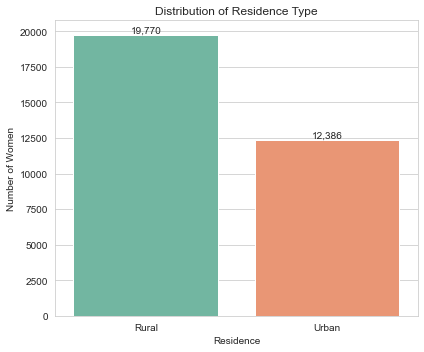

Rural    61.5
Urban    38.5
Name: residence_type, dtype: float64


In [61]:
# --------------------------------------
# Residence Type
# --------------------------------------

plt.figure(figsize=(6,5))
ax = sns.countplot(data=df, x='residence_type', order=['Rural', 'Urban'])

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title("Distribution of Residence Type")
plt.xlabel("Residence")
plt.ylabel("Number of Women")
plt.tight_layout()
plt.savefig('images/residence_distribution.png', dpi=120)
plt.show()

print((df['residence_type'].value_counts(normalize=True) * 100).round(1))

##### Insight
About 62% of the women live in rural areas and 38% in urban areas which reflects that the dataset contains respondents from both rural and urban settings, ensuring geographical diversity.Rural respondents form the majority. Residence type may influence contraceptive use due to differences in healthcare accessibility, availability of family planning services, education levels, and economic opportunities. This variable is therefore expected to contribute meaningful information during classification.

#### Bivariate Analysis

In this section, we examine how contraceptive use differs across different groups. For each group, two bars are displayed: one representing the percentage of women using a modern contraceptive method and the other representing the percentage not using a modern method. Together, these percentages add up to 100%.

Percentages are used instead of raw numbers because each group has a different number of women. Using counts could make larger groups appear to have higher contraceptive use simply because they include more people. By using percentages, it is easier to compare contraceptive use fairly across groups. The percentage of women using a modern contraceptive method is also an important measure that public health professionals commonly use to monitor family planning programs

##### Defining the Modelling Target

As we set out in our proposal, we frame the target as a simple **modern method vs not** outcome. There are two reasons for this. First, it matches the modern contraceptive prevalence rate (mCPR), which is the measure the Ministry of Health and partners like UNFPA and FP2030 actually track. Second, the folkloric group has only 53 women, which is far too few to predict or to oversample meaningfully, so a full four-class model would not be reliable.

We still show the full four-class breakdown in the univariate section (5.1), so the overall picture is not lost. Traditional and folkloric users are grouped here with the non-users as "not using a modern method". This binary target still has some imbalance (about 38% modern vs 62% not), which we handle later using SMOTE on the training data only.

In [62]:
# creating a simple yes/no column: 1 if she uses a modern method, 0 otherwise
df['uses_modern'] = (df['contraceptive_use'] == 'Modern').astype(int)

# a small helper so we do not repeat the plotting code for every group.
# it shows, within each group, the share using a modern method and the share not using one
# (the two always add up to 100%).
def modern_vs_not_plot(column, order, title, filename):
    share = (df.groupby(column)['uses_modern']
               .value_counts(normalize=True)
               .rename('proportion')
               .reset_index())
    share['Method'] = share['uses_modern'].map({1: 'Modern', 0: 'Not modern'})
    share['percent'] = share['proportion'] * 100

    plt.figure(figsize=(8,5))
    ax = sns.barplot(data=share, x=column, y='percent', hue='Method',
                     order=order, hue_order=['Modern', 'Not modern'])

    # writing the percentage on top of each bar
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{p.get_height():.0f}%',
                        (p.get_x() + p.get_width()/2, p.get_height()),
                        ha='center', va='bottom', fontsize=9)

    plt.title(title)
    plt.ylabel("% of women in the group")
    plt.xlabel(column.replace('_', ' ').title())
    plt.legend(title="")
    plt.tight_layout()
    plt.savefig(f'images/{filename}.png', dpi=120)
    plt.show()

#### 5.6 Modern vs Not-modern Use by Education Level

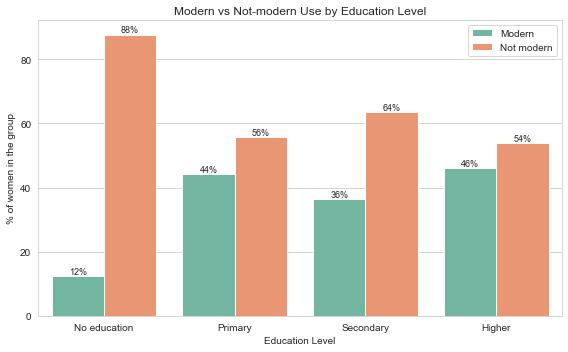

In [63]:
modern_vs_not_plot('education_level',
                   ['No education', 'Primary', 'Secondary', 'Higher'],
                   "Modern vs Not-modern Use by Education Level",
                   "use_by_education")

##### Insight
The clearest gap is between women with no education (only about 12% use a modern method) and women with any education (around 37 to 46%). The rise is not a straight line though, primary-educated women (44%) are actually a bit higher than secondary-educated women (37%). This is probably because many secondary-age women are younger and not yet married. The main takeaway is that having no education is strongly linked to very low modern use.

#### 5.7 Modern vs Not-modern Use by Wealth Index

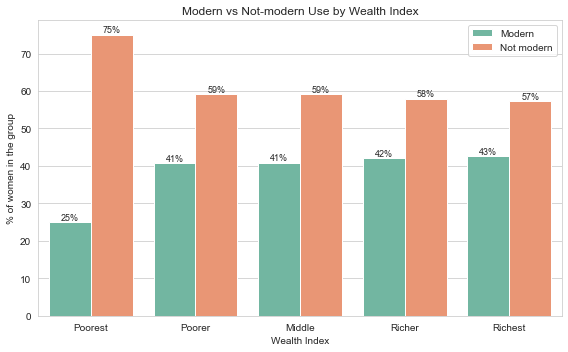

In [64]:
modern_vs_not_plot('wealth_index',
                   ['Poorest', 'Poorer', 'Middle', 'Richer', 'Richest'],
                   "Modern vs Not-modern Use by Wealth Index",
                   "use_by_wealth")

##### Insight
The poorest women stand out with the lowest modern use (about 25%). Above the poorest group, the rate is fairly flat at around 41 to 43%. So the big wealth gap is between the poorest and everyone else, not a steady climb from poor to rich.

#### 5.8 Modern vs Not-modern Use by Residence Type

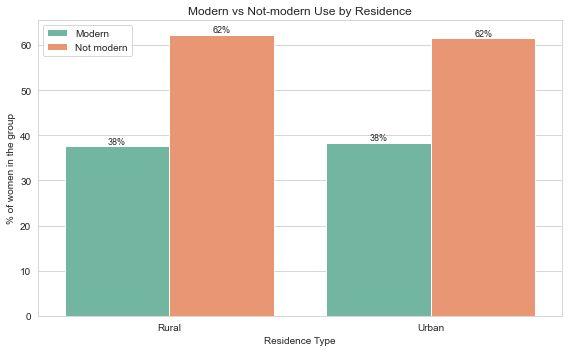

In [65]:
modern_vs_not_plot('residence_type',
                   ['Rural', 'Urban'],
                   "Modern vs Not-modern Use by Residence",
                   "use_by_residence")

##### Insight
Urban and rural women use modern methods at almost exactly the same rate (about 38% each). So on its own, where a woman lives barely makes a difference. This is a useful finding: any urban/rural gap people expect is likely explained by other things like education and wealth, not by residence itself. We check this properly in the multivariate section.

#### 5.9 Modern Use by County

**Business Question 2** : which counties have the lowest use, and therefore the highest non-use?

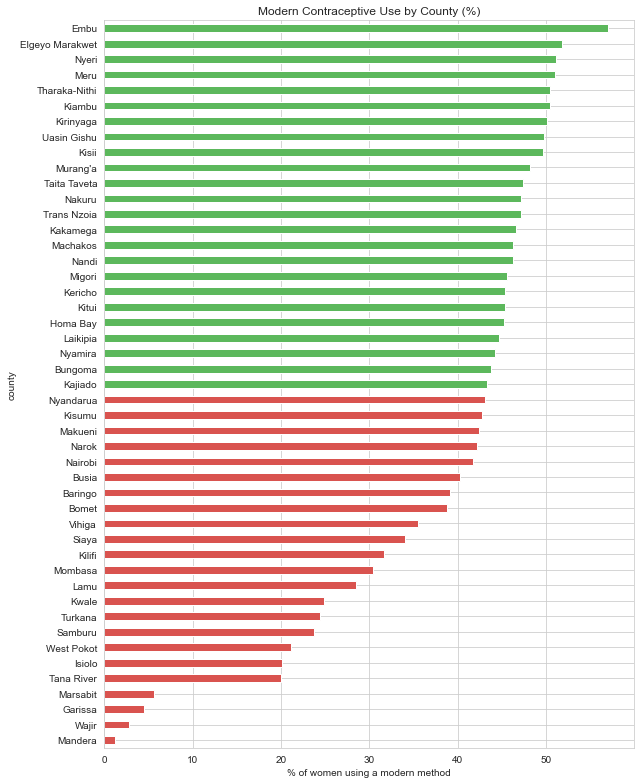

Lowest 5 counties:
county
Mandera        1.2
Wajir          2.8
Garissa        4.5
Marsabit       5.6
Tana River    20.0
Name: uses_modern, dtype: float64

Highest 5 counties:
county
Tharaka-Nithi      50.5
Meru               51.0
Nyeri              51.0
Elgeyo Marakwet    51.8
Embu               57.0
Name: uses_modern, dtype: float64


In [66]:
# working out the modern-use rate for each county and sorting from lowest to highest
county_rate = df.groupby('county')['uses_modern'].mean().mul(100).sort_values()

plt.figure(figsize=(9, 11))
colors = ['#d9534f' if v < county_rate.median() else '#5cb85c' for v in county_rate]
county_rate.plot(kind='barh', color=colors)
plt.title("Modern Contraceptive Use by County (%)")
plt.xlabel("% of women using a modern method")
plt.tight_layout()
plt.savefig('images/use_by_county.png', dpi=120)
plt.show()

print("Lowest 5 counties:")
print(county_rate.head().round(1))
print("\nHighest 5 counties:")
print(county_rate.tail().round(1))

##### Insight
County makes a huge difference. Modern use runs from about 1% in Mandera and under 6% in Wajir, Garissa and Marsabit (all in the arid north) up to around 50 to 57% in counties like Embu, Meru, Nyeri and Elgeyo Marakwet. This wide gap is exactly why it makes sense to target family planning by county, and it lines up with the problem we described at the start.

### Multivariate Analysis

Here we have looked at variables together instead of one at a time.

#### 5.10 Education and Wealth Together

**Business Question 3**: do education and wealth reinforce each other, or does one matter more?

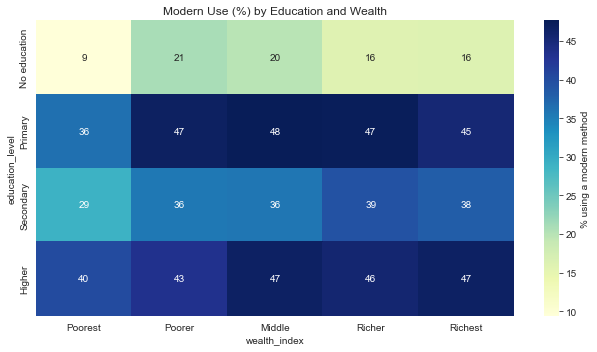

In [67]:
# average modern-use rate for every education-and-wealth combination
pivot = (df.pivot_table(index='education_level', columns='wealth_index',
                        values='uses_modern', aggfunc='mean') * 100)
pivot = pivot.reindex(index=['No education', 'Primary', 'Secondary', 'Higher'],
                      columns=['Poorest', 'Poorer', 'Middle', 'Richer', 'Richest'])

plt.figure(figsize=(9,5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu',
            cbar_kws={'label': '% using a modern method'})
plt.title("Modern Use (%) by Education and Wealth")
plt.tight_layout()
plt.savefig('images/education_x_wealth.png', dpi=120)
plt.show()

##### Insight
Reading across the heatmap, education matters more than wealth. Among women with no education, modern use stays low (about 9 to 21%) no matter how wealthy they are. Once a woman has some education, the rate jumps into the 35 to 48% range across all wealth groups. So education is the stronger lever, and being in the poorest group is the main place where wealth pulls use down. In other words, raising incomes alone would probably not be enough on its own.

#### 5.11 Correlation Between Numeric Variables

Checking whether any numeric variables carry the same information, which we would need to watch out for when modelling.

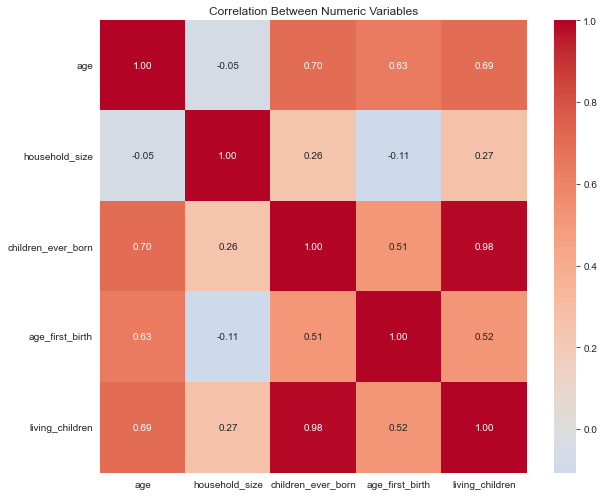

In [68]:
# --------------------------------------
# Correlation Matrix
# --------------------------------------

numeric_cols = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(9,7))
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Correlation Between Numeric Variables")
plt.tight_layout()
plt.savefig('images/correlation.png', dpi=120)
plt.show()

##### Insight
Most of the numeric variables are only weakly related, so each one adds its own information. The one strong relationship is between `children_ever_born` and `living_children` (about 0.98), which makes sense because they measure almost the same thing. To avoid this overlap (multicollinearity), we will keep only one of them for the models that are sensitive to it.

### EDA Brief Summary

* The data shows an imbalance in the target variable, so we predict **modern contraceptive use versus not using a modern method** and apply SMOTE only to the training data to address the imbalance.
* **Education** and **county** show the strongest relationship with modern contraceptive use, while **wealth** has a moderate effect and **place of residence** has only a small independent effect.
* Some variables contain overlapping information, so redundant features are removed, and the remaining variables are encoded appropriately before building the machine learning models.
